## Collaborative Filtering (User-Based Recommendation system)

pip install scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
movies_df = pd.read_csv('movies 2.csv')
movies_df

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
62418,209157,We (2018),Drama
62419,209159,Window of the Soul (2001),Documentary
62420,209163,Bad Poems (2018),Comedy|Drama
62421,209169,A Girl Thing (2001),(no genres listed)


In [4]:
movies_df = movies_df.head(10000)
movies_df

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9995,33750,Innocent Voices (Voces inocentes) (2004),Drama|War
9996,33755,Godzilla vs. Biollante (Gojira vs. Biorante) (...,Action|Sci-Fi
9997,33760,Anna and the King of Siam (1946),Drama|Romance
9998,33767,Good Neighbor Sam (1964),Comedy


In [ ]:
# Load the MovieLens dataset  
ratings = pd.read_csv('ratings.csv')
ratings = ratings.head(10000)
ratings

## pivot table or user-item interaction matrix

A pivot table, also known as a user-item interaction matrix in the context of recommendation systems, is a two-dimensional table that represents the interactions between users and items. Each cell in the table corresponds to the interaction (e.g., a rating, purchase, or view) that a particular user has with a specific item.

In the context of recommendation systems:

Users: Represent individuals or entities for whom recommendations are being made (e.g., users of a website, customers of an e-commerce platform).

Items: Represent the objects, products, or content for which recommendations are generated (e.g., movies, books, products).

The pivot table captures the user-item interactions by arranging users along one axis and items along the other. The cells in the table contain the recorded interactions, such as ratings or binary indicators (1 for interaction, 0 for no interaction).

Here's a simple example of a user-item interaction matrix:

<img src="pivot table.png"/>


In [5]:
# Create user-item interaction matrix
user_item_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating', fill_value=0)
user_item_matrix

movieId,1,2,3,5,6,7,9,10,11,14,...,182715,182823,187541,187593,189333,195159,200818,200838,203375,203519
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,3.5,4.5,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.5,0.0,3.5,3.5,4.0,5.0,5.0,3.0,4.5,2.5
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
72,0.0,2.0,0.0,0.0,4.0,4.0,0.0,0.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
73,3.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Standardize the user-item matrix
scaler = StandardScaler()
user_item_matrix_standardized = scaler.fit_transform(user_item_matrix)
print((user_item_matrix_standardized))

[[-0.64448164 -0.35294556 -0.28572633 ... -0.11624764 -0.11624764
  -0.11624764]
 [ 1.41864555 -0.35294556 -0.28572633 ... -0.11624764 -0.11624764
  -0.11624764]
 [ 1.71337801 -0.35294556 -0.28572633 ... -0.11624764 -0.11624764
  -0.11624764]
 ...
 [ 1.1239131  -0.35294556 -0.28572633 ... -0.11624764 -0.11624764
  -0.11624764]
 [-0.64448164 -0.35294556 -0.28572633 ... -0.11624764 -0.11624764
  -0.11624764]
 [ 2.30284292 -0.35294556 -0.28572633 ... -0.11624764 -0.11624764
  -0.11624764]]


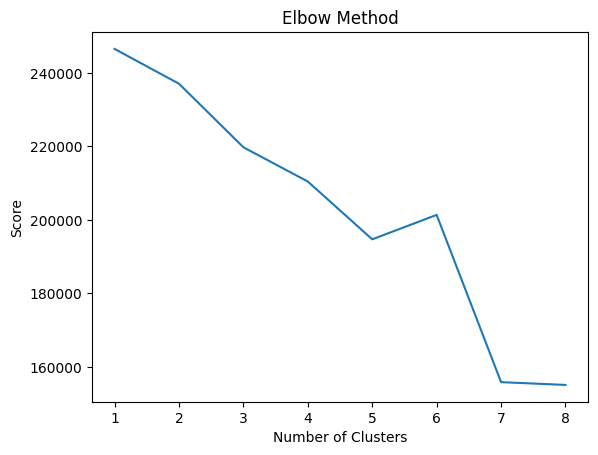

In [7]:
def elbow_method(data):
    """
    This is the function used to get optimal number of clusters in order to feed to the k-means clustering algorithm.
    """

    number_clusters = range(1, 9)  # Range of possible clusters that can be generated
    kmeans = [KMeans(n_init='auto',n_clusters=i) for i in number_clusters] # Getting no. of clusters 

    score = [kmeans[i].fit(data).score(data) for i in range(len(kmeans))] # Getting score corresponding to each cluster.
    score = [i*-1 for i in score] # Getting list of positive scores.
    
    plt.plot(number_clusters, score)
    plt.xlabel('Number of Clusters')
    plt.ylabel('Score')
    plt.title('Elbow Method')
    plt.show()
    
elbow_method(user_item_matrix_standardized)

In [8]:
# Perform k-means clustering
kmeans = KMeans(n_clusters=4, random_state=42,n_init=10)
user_clusters = kmeans.fit_predict(user_item_matrix_standardized)
user_clusters

array([0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0], dtype=int32)

In [9]:
# Calculate cosine similarity based on cluster centroids
cluster_centers = kmeans.cluster_centers_
user_similarity = cosine_similarity(cluster_centers)

In [10]:
# Function to recommend movies for a given user based on cluster similarity

def recommend_movies_cluster(user_id, user_similarity, user_clusters, n=5):
    
    # Python uses 0-based indexing, meaning the index of the first element in an array or list is 0. 
    # If user_id starts from 1, subtracting 1 from it aligns it with the 0-based indexing used in Python.
    
    user_cluster = user_clusters[user_id - 1]
    # print("User cluster",user_cluster)
    
    similar_users = np.where(user_clusters == user_cluster)[0]
    
    # Exclude the user itself from recommendations
    similar_users = similar_users[similar_users != (user_id - 1)]

    # Calculate mean ratings of similar users
    mean_ratings = user_item_matrix.iloc[similar_users].mean(axis=0)
    
    # Find unrated movies by the user
    unrated_movies = (user_item_matrix.iloc[user_id - 1] == 0)

    # Recommend movies based on mean ratings
    recommendations_idx = mean_ratings[unrated_movies].sort_values(ascending=False).index[:n]
    recommendations = [movies_df.loc[movie_id, 'title'] for movie_id in recommendations_idx]
    return recommendations


In [13]:
# Example: Recommend movies for user 1 based on k-means clustering
user_id_to_recommend = 55
recommendations = recommend_movies_cluster(user_id_to_recommend, user_similarity, user_clusters, n=5)
print(f"Top 5 movie recommendations for User {user_id_to_recommend} based on k-means clustering:")
count = 0
for movie in recommendations:
    count += 1 
    print(f"Movie{count} :",movie)

Top 5 movie recommendations for User 55 based on k-means clustering:
Movie1 : Ladybird Ladybird (1994)
Movie2 : Quiz Show (1994)
Movie3 : Wooden Man's Bride, The (Yan shen) (1994)
Movie4 : It Could Happen to You (1994)
Movie5 : It Came from Beneath the Sea (1955)


*************************************************************************

*************************************************************************

*************************************************************************

## Content-based recommendation system

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
movies = pd.read_csv('movies 2.csv')
# movies = movies.head(1500)
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
62418,209157,We (2018),Drama
62419,209159,Window of the Soul (2001),Documentary
62420,209163,Bad Poems (2018),Comedy|Drama
62421,209169,A Girl Thing (2001),(no genres listed)


In [10]:
len(movies.genres.unique())

1639

In [11]:
# Create a TF-IDF vectorizer for movie genres
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(movies['genres'])

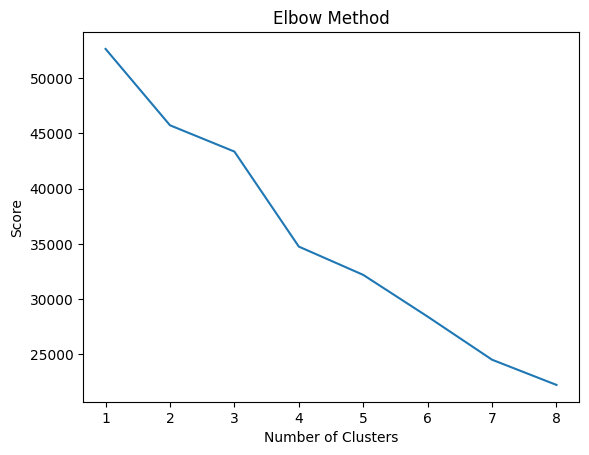

In [12]:
def elbow_method(Y_sklearn):
    """
    This is the function used to get optimal number of clusters in order to feed to the k-means clustering algorithm.
    """

    number_clusters = range(1, 9)  # Range of possible clusters that can be generated
    kmeans = [KMeans(n_init='auto',n_clusters=i) for i in number_clusters] # Getting no. of clusters 

    score = [kmeans[i].fit(Y_sklearn).score(Y_sklearn) for i in range(len(kmeans))] # Getting score corresponding to each cluster.
    score = [i*-1 for i in score] # Getting list of positive scores.
    
    plt.plot(number_clusters, score)
    plt.xlabel('Number of Clusters')
    plt.ylabel('Score')
    plt.title('Elbow Method')
    plt.show()
    
elbow_method(tfidf_matrix)

In [13]:
tfidf_matrix

<62423x23 sparse matrix of type '<class 'numpy.float64'>'
	with 121317 stored elements in Compressed Sparse Row format>

In [14]:
# Perform k-means clustering on the TF-IDF matrix
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
movie_clusters = kmeans.fit_predict(tfidf_matrix)
movie_clusters

array([4, 4, 2, ..., 2, 3, 4], dtype=int32)

In [15]:
# Calculate cosine similarity based on cluster centroids
cluster_centers = kmeans.cluster_centers_
movie_similarity = cosine_similarity(cluster_centers)
len(movie_similarity)

5

In [16]:
# Print the cluster labels for all movies
print("Movie Clusters:", movie_clusters)

Movie Clusters: [4 4 2 ... 2 3 4]


In [17]:
# Print the size of the movie_clusters array
print("Size of movie_clusters:", movie_clusters.shape)

Size of movie_clusters: (62423,)


In [30]:
def recommend_movies_content(movie_title, movie_similarity, movie_clusters, movies_df, n=5):
    # Find the movie in the dataset
    movie_row = movies_df[movies_df['title'] == movie_title]
    
    if not movie_row.empty:
        movie_idx = movie_row.index[0]
        print("Movie Index:", movie_idx)

        # Check if the movie index is within the valid range
        if movie_idx < len(movies_df):
            movie_cluster = movie_clusters[movie_idx]
            # print("Movie Cluster:", movie_cluster)

            # Find movies in the same cluster as the given movie
            similar_movies = np.where(movie_clusters == movie_cluster)[0]
            # print("Similar movies before exclusion:", similar_movies)

            # Exclude the given movie itself from recommendations
            similar_movies = similar_movies[similar_movies != movie_idx]
            # print("Similar movies after exclusion:", similar_movies)

            # Recommend movies based on mean similarity
            recommendations_idx = np.sort(similar_movies)[:5]
            recommendations = movies['title'].iloc[recommendations_idx].tolist()

            return recommendations
        else:
            print(f"Movie index '{movie_idx}' is out of bounds.")
            return []
    else:
        print(f"Movie '{movie_title}' not found in the dataset.")
        return []

In [31]:
# Example: Recommend movies similar to 'Trial and Error (1997)' based on content
movie_title = "Nixon (1995)"
content_recommendations = recommend_movies_content(movie_title, movie_similarity, movie_clusters, movies, n=5)

print(f"Top 5 content-based recommendations for '{movie_title}':")
count = 0
for movie in content_recommendations:
    count += 1 
    print(f"Movie{count} :",movie)

Movie Index: 13
Top 5 content-based recommendations for 'Nixon (1995)':
Movie1 : Casino (1995)
Movie2 : Sense and Sensibility (1995)
Movie3 : Leaving Las Vegas (1995)
Movie4 : Othello (1995)
Movie5 : Now and Then (1995)
